In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import (LabelEncoder, OneHotEncoder,StandardScaler, MinMaxScaler,RobustScaler, PowerTransformer)
from sklearn.model_selection import train_test_split
import category_encoders as ce



# **EDA**

In [2]:
df = pd.read_csv(r"D:\Uni_Projects\Ass Machine\Data\car_price.csv")

In [3]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017.0,12500.0,Manual,15735.0,Petrol,150.0,55.4,1.4,audi
1,A6,2016.0,16500.0,Automatic,36203.0,Diesel,20.0,64.2,2.0,audi
2,A1,2016.0,11000.0,Manual,29946.0,Petrol,30.0,55.4,1.4,audi
3,A4,2017.0,16800.0,Automatic,25952.0,Diesel,145.0,67.3,2.0,audi
4,A3,2019.0,17300.0,Manual,1998.0,Petrol,145.0,49.6,1.0,audi


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72435 entries, 0 to 72434
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         68814 non-null  object 
 1   year          68813 non-null  float64
 2   price         68814 non-null  float64
 3   transmission  68812 non-null  object 
 4   mileage       68813 non-null  float64
 5   fuelType      68813 non-null  object 
 6   tax           68814 non-null  float64
 7   mpg           68814 non-null  float64
 8   engineSize    68813 non-null  float64
 9   Make          68814 non-null  object 
dtypes: float64(6), object(4)
memory usage: 5.5+ MB


In [5]:
df.shape

(72435, 10)

In [6]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,68813.000000,68814.000000,68813.000000,68814.000000,68814.000000,68813.000000
mean,2017.077660,16583.919261,23179.439539,116.930421,55.836352,1.635373
std,2.099474,9304.412707,21347.569657,64.081931,17.043643,0.561734
min,1996.000000,495.000000,1.000000,0.000000,0.300000,0.000000
25%,2016.000000,10167.250000,7199.000000,30.000000,47.900000,1.200000
50%,2017.000000,14495.000000,17521.000000,145.000000,55.400000,1.600000
75%,2019.000000,20359.750000,32478.000000,145.000000,62.800000,2.000000
max,2020.000000,145000.000000,323000.000000,580.000000,470.800000,6.600000


In [7]:
df.describe(include="O")

,model,transmission,fuelType,Make
count,68814,68812,68813,68814
unique,145,4,5,7
top,Fiesta,Manual,Petrol,Ford
freq,6225,40839,38390,17045


In [8]:
df.isnull().sum()

model           3621
year            3622
price           3621
transmission    3623
mileage         3622
fuelType        3622
tax             3621
mpg             3621
engineSize      3622
Make            3621
dtype: int64

The dataset exhibits a significant amount of missing data across multiple features. Pre-processing and imputation are required to handle these nulls before proceeding with further analysis or training

<Axes: >

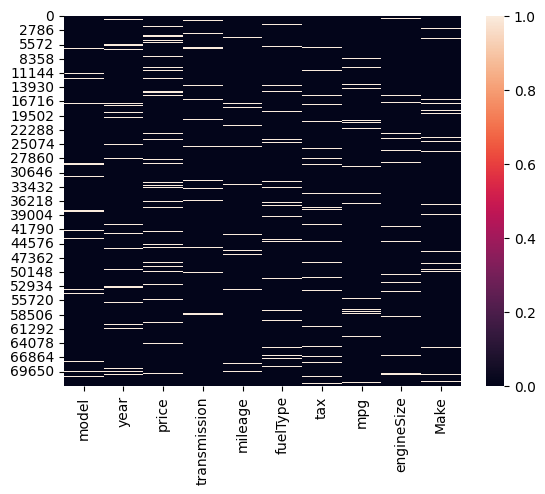

In [9]:
sns.heatmap(df.isnull())

"The heatmap reveals a widespread distribution of missing values across most features, indicating that a significant portion of the rows contains incomplete data which requires careful handling

In [10]:
df.duplicated().sum()

np.int64(366)

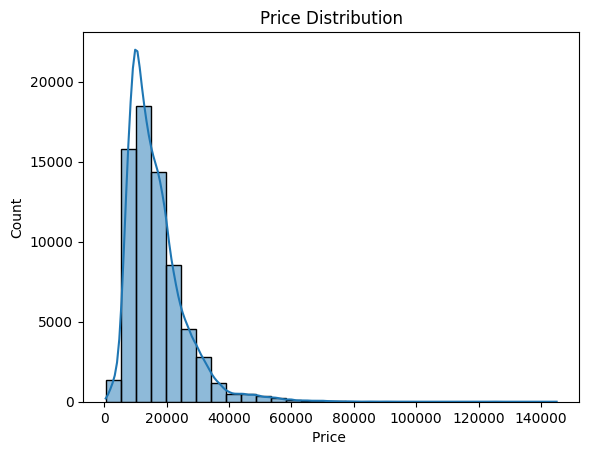

In [11]:
sns.histplot(df['price'], bins=30, kde=True)
plt.xlabel("Price ")
plt.title("Price Distribution")
plt.show()

"The price distribution is positively skewed (right-skewed), indicating that most listings are concentrated at lower price points with a few high-priced outliers forming a long tail.

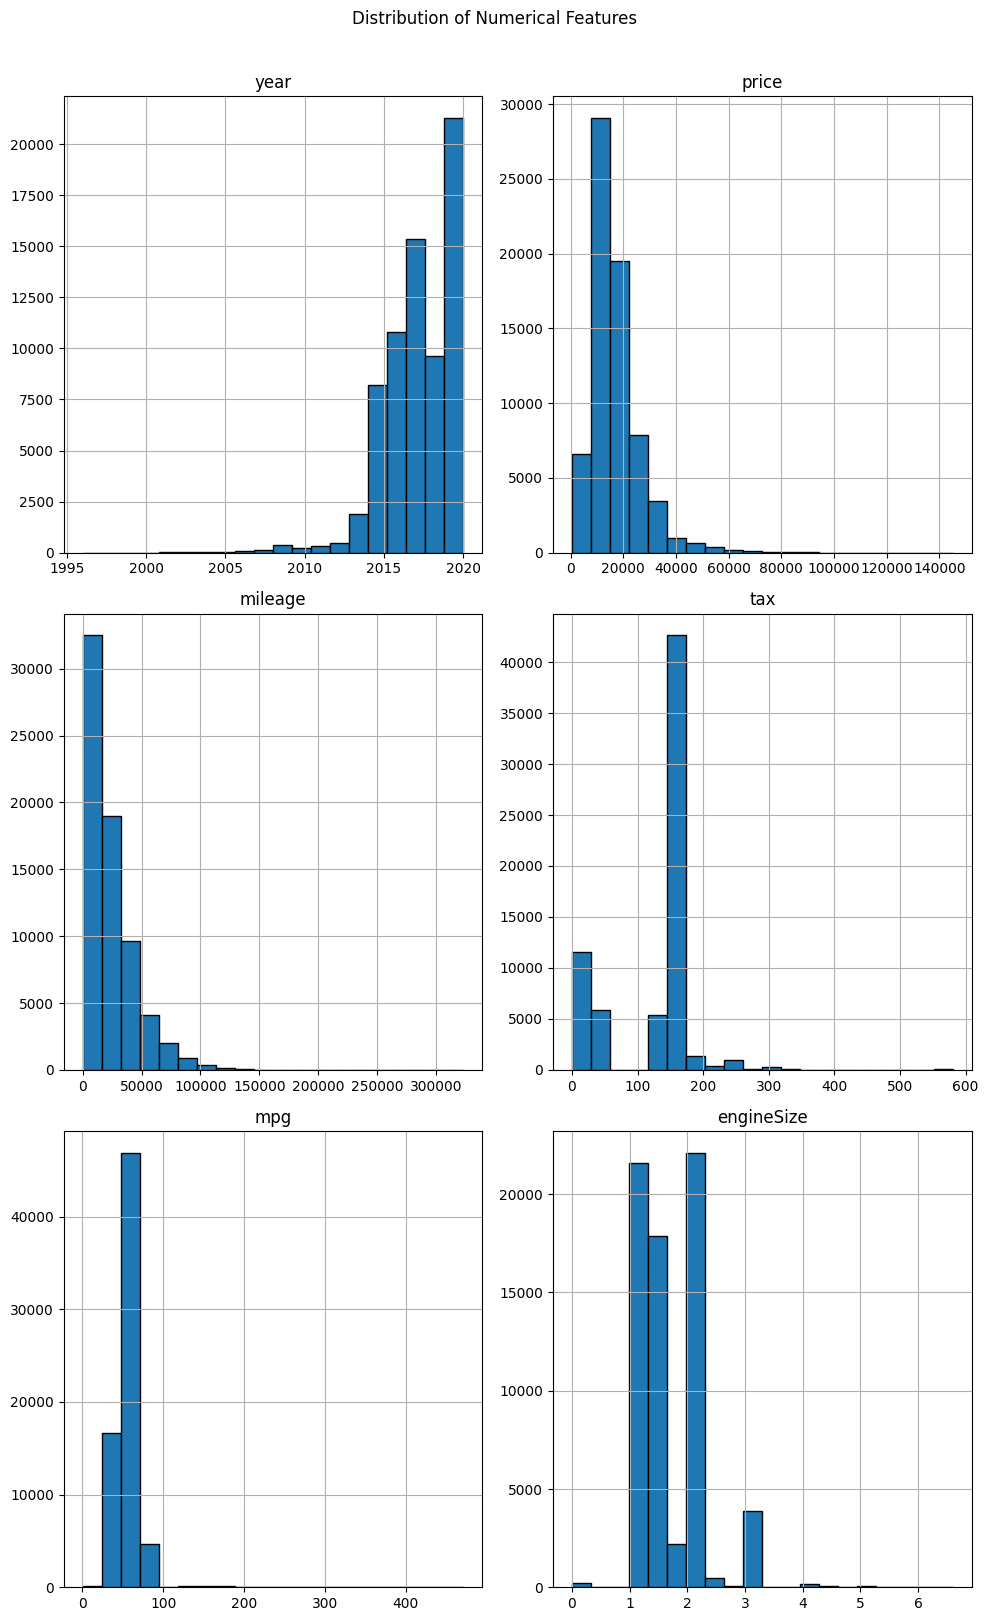

In [12]:
num_cols = df.select_dtypes(include=np.number).columns.to_list()
df[num_cols].hist(figsize=(10,16), bins= 20 , edgecolor='black')
plt.suptitle("Distribution of Numerical Features", y=1.01)
plt.tight_layout()
plt.show()

"The numerical features exhibit various non-normal distributions, with most variables being significantly skewed—such as Price and Mileage being right-skewed—highlighting the need for data transformation and scaling before modeling

"Certain features like Tax, EngineSize, and mpg show high concentration around specific discrete values, suggesting standard categorizations or common specifications across the majority of the vehicle records

In [13]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017.0,12500.0,Manual,15735.0,Petrol,150.0,55.4,1.4,audi
1,A6,2016.0,16500.0,Automatic,36203.0,Diesel,20.0,64.2,2.0,audi
2,A1,2016.0,11000.0,Manual,29946.0,Petrol,30.0,55.4,1.4,audi
3,A4,2017.0,16800.0,Automatic,25952.0,Diesel,145.0,67.3,2.0,audi
4,A3,2019.0,17300.0,Manual,1998.0,Petrol,145.0,49.6,1.0,audi


"The boxplot indicates a uniform price distribution across all car brands. The median prices are relatively consistent, and the interquartile range (IQR) shows similar variability for each brand, suggesting that brand name is not a significant differentiator for price in this dataset.

Text(0.5, 1.0, 'Fuel Type count')

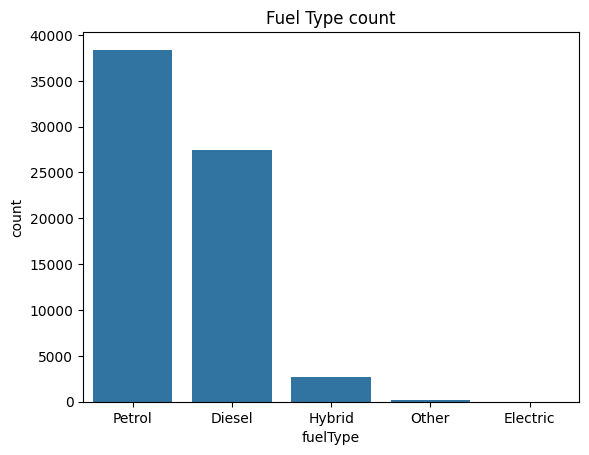

In [14]:
sns.countplot(data=df, x='fuelType')
plt.title("Fuel Type count")

"Petrol is the most prevalent fuel type, followed by Diesel, whereas Hybrid and Electric vehicles represent only a minimal fraction of the total inventory

Text(0.5, 1.0, 'Transmission count')

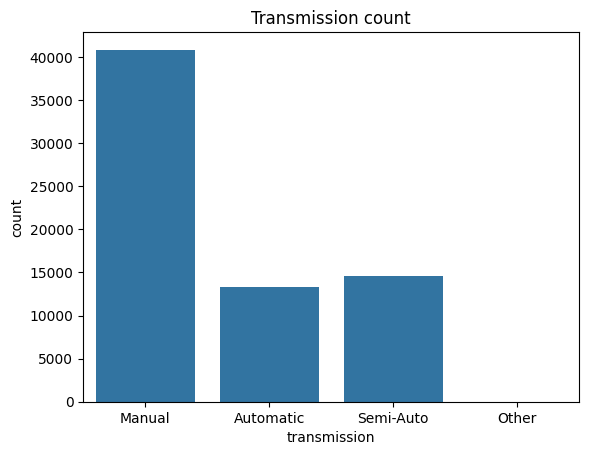

In [15]:
sns.countplot(data= df, x = 'transmission')
plt.title("Transmission count")


"Manual transmissions dominate the dataset, accounting for the vast majority of listings, while Automatic and Semi-Automatic options are significantly less frequent

Text(0.5, 1.0, 'Transmission count')

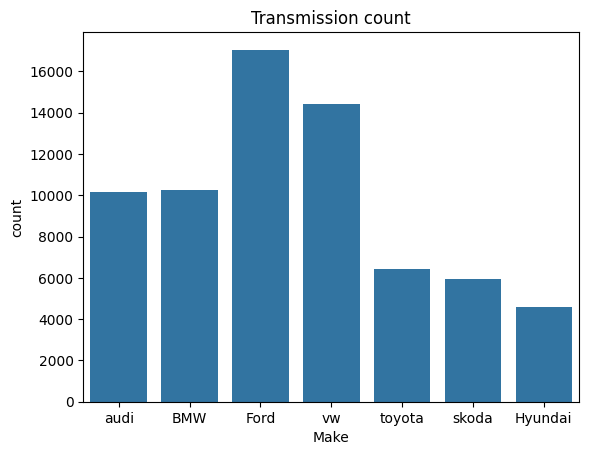

In [16]:
sns.countplot(data= df, x = 'Make')
plt.title("Transmission count")

Ford and VW are the most represented brands in the dataset, while Hyundai shows the lowest count among the listed manufacturers.

In [17]:
df

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017.0,12500.0,Manual,15735.0,Petrol,150.0,55.4,1.4,audi
1,A6,2016.0,16500.0,Automatic,36203.0,Diesel,20.0,64.2,2.0,audi
2,A1,2016.0,11000.0,Manual,29946.0,Petrol,30.0,55.4,1.4,audi
3,A4,2017.0,16800.0,Automatic,25952.0,Diesel,145.0,67.3,2.0,audi
4,A3,2019.0,17300.0,Manual,1998.0,Petrol,145.0,49.6,1.0,audi
...,...,...,...,...,...,...,...,...,...,...
72430,I30,2016.0,8680.0,Manual,25906.0,Diesel,0.0,78.4,1.6,Hyundai
72431,I40,2015.0,7830.0,Manual,NaN,Diesel,30.0,65.7,1.7,Hyundai
72432,I10,2017.0,6830.0,Manual,13810.0,Petrol,20.0,60.1,1.0,NaN
72433,Tucson,2018.0,13994.0,Manual,23313.0,Petrol,145.0,44.8,1.6,Hyundai


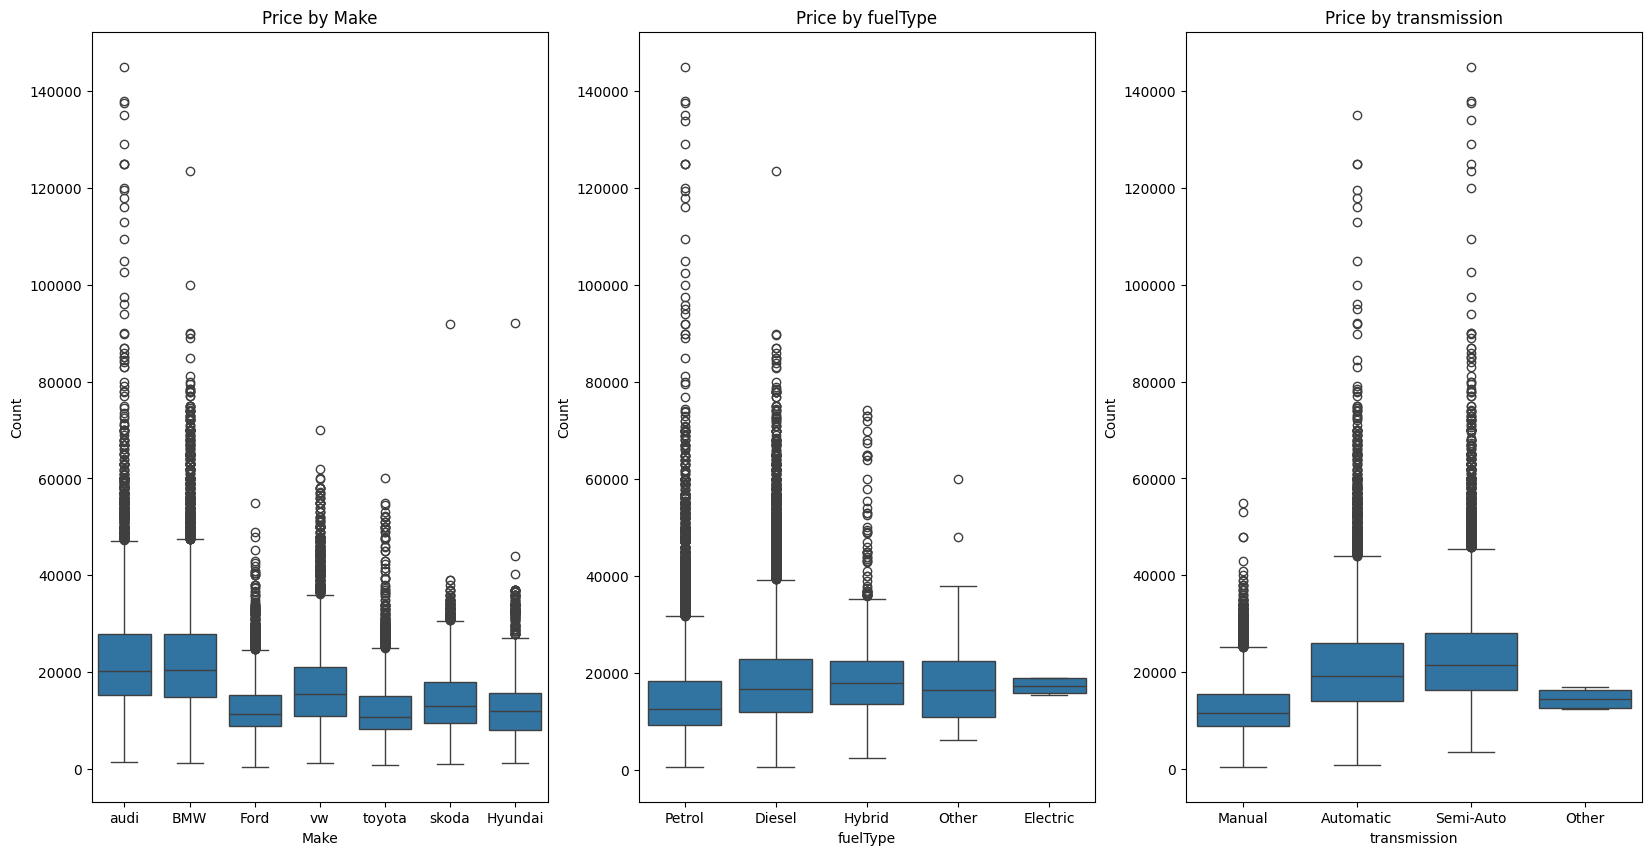

In [18]:
figs,axes =plt.subplots(1,3,figsize=(20,10))
features =['Make', 'fuelType', 'transmission']
for ax, col in zip(axes.flatten(), features):
    sns.boxplot(data = df, x=col, y='price',ax=ax)
    ax.set_title(f"Price by {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
plt.show()

 1 "Premium brands like Audi and BMW exhibit higher median prices and a significant number of high-value outliers

 2 "Hybrid and Diesel vehicles show a slightly higher median price, while Petrol engines account for the widest range of price outliers.
 
 3 "Automatic and Semi-Automatic transmissions command higher market prices than Manual cars, which are concentrated in the lower price segment

"The box plots highlight that vehicle price is significantly influenced by brand, fuel type, and transmission, while also revealing a large presence of extreme outliers across all categories

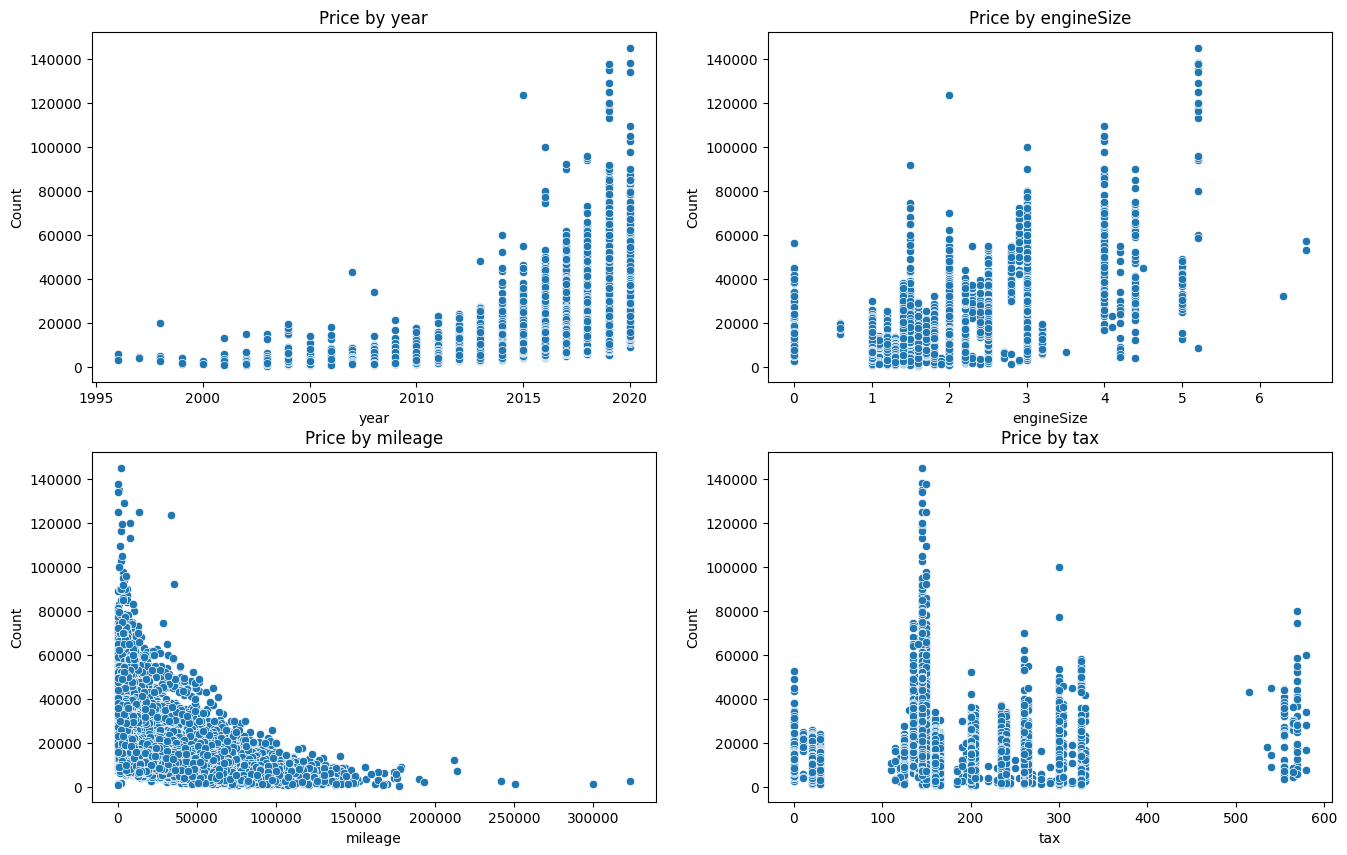

In [19]:
figs,axes =plt.subplots(2,2,figsize=(16,10))
features =['year', 'engineSize', 'mileage','tax','mpg']
for ax, col in zip(axes.flatten(), features):
    sns.scatterplot(data = df, x=col, y='price',ax=ax)
    ax.set_title(f"Price by {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
plt.show()

1 "There is a strong positive correlation between year and price, as newer models command significantly higher market value

2 "Price shows a clear negative correlation with mileage, where vehicles with lower mileage maintain higher price points.

3 "Larger engine sizes generally correspond to higher price tiers, though the data is clustered around standard engine capacities.

4 "The relationship between tax and price is less linear, with most high-priced listings concentrated within specific tax brackets.

<Axes: >

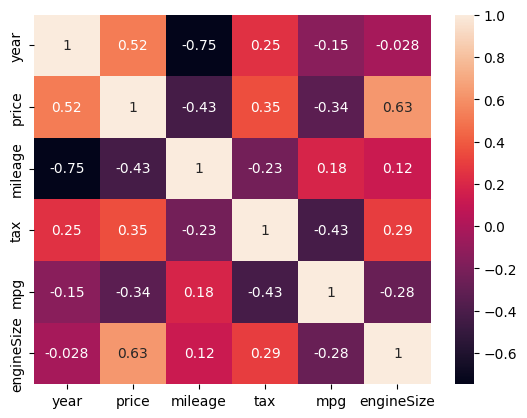

In [20]:
sns.heatmap(df.corr(numeric_only=True), annot= True)

"The heatmap indicates that Price has a strong positive correlation with EngineSize (0.63) and Year (0.52), while showing a notable negative correlation with Mileage (-0.43) and MPG (-0.34)

"Since Year and Mileage are highly correlated (-0.75), we might drop one of them to avoid Multicollinearity, which can destabilize the regression model.

# **Data Preprocessing**

In [21]:
df['car_age'] = 2026 - df['year']
df.drop('year', axis=1, inplace=True)


### Train/test split

In [22]:
df.drop_duplicates(inplace=True)

In [23]:
df.duplicated().sum()

np.int64(0)

In [24]:
x = df.drop(columns='price')
y = df[['price']]
x 
y


,price
0,12500.0
1,16500.0
2,11000.0
3,16800.0
4,17300.0
...,...
72430,8680.0
72431,7830.0
72432,6830.0
72433,13994.0


In [25]:
x_train , x_test , y_train , y_test = train_test_split( x, y , test_size=0.2 ,random_state= 1)


In [26]:
print(f"Train: {x_train.shape} | Test: {x_test.shape}")

Train: (57655, 9) | Test: (14414, 9)


# **Outliers Handling & Skewness Transformation** #

<Axes: xlabel='car_age', ylabel='price'>

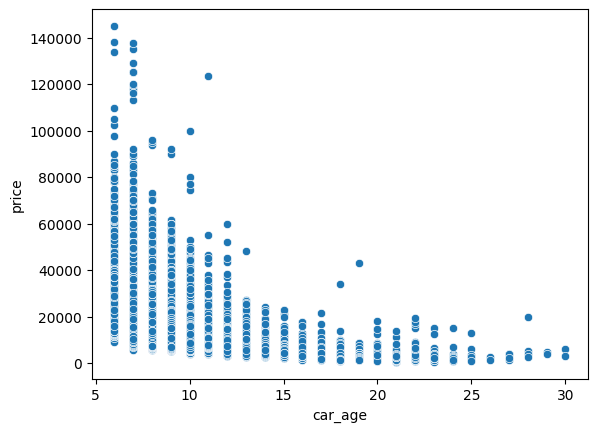

In [27]:
sns.scatterplot(data=df ,x='car_age',y='price')

<Axes: xlabel='car_age', ylabel='Count'>

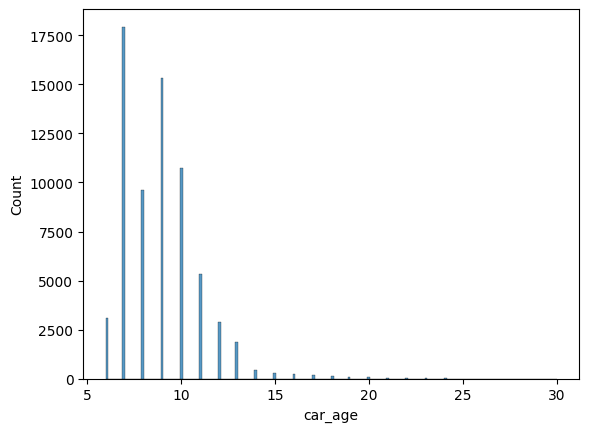

In [28]:
sns.histplot(data=df, x='car_age')

"The 'year' feature was converted into 'car_age' to better capture the depreciation logic, followed by a log transformation to normalize its right-skewed distribution and linearize its relationship with price, which significantly improves the performance of the linear regression model."

In [29]:
x_train

,model,transmission,mileage,fuelType,tax,mpg,engineSize,Make,car_age
41911,Golf,Manual,500.0,Petrol,145.0,46.3,1.5,vw,6.0
6839,Q3,Semi-Auto,4750.0,Petrol,145.0,31.7,2.0,audi,7.0
693,TT,Manual,19383.0,Petrol,165.0,46.3,2.0,audi,11.0
33529,Fiesta,Manual,19309.0,Diesel,145.0,88.3,1.5,Ford,7.0
28776,Fiesta,Manual,33490.0,Petrol,125.0,54.3,1.2,Ford,11.0
...,...,...,...,...,...,...,...,...,...
49335,Polo,Manual,97000.0,Petrol,165.0,43.5,1.4,vw,18.0
20720,1 Series,Manual,17863.0,Diesel,NaN,83.1,1.5,BMW,10.0
21551,Kuga,Manual,26597.0,Diesel,145.0,54.3,2.0,Ford,9.0
50297,NaN,Manual,15786.0,Diesel,125.0,58.9,2.0,vw,9.0


In [30]:
skewed_cols = ['mileage','mpg', 'car_age']
for col in skewed_cols:
    x_train[col] = np.log1p(x_train[col])
    x_test[col] = np.log1p(x_test[col])

y_train = np.log1p(y_train)
y_test = np.log1p(y_test)

"Log transformation was applied to highly skewed numerical features to approximate a normal distribution and stabilize variance, ensuring that the linear regression model is not biased by extreme outliers and can more accurately capture the underlying patterns in the data."

In [31]:
y_train

,price
41911,9.903288
6839,10.432674
693,9.711055
33529,9.391912
28776,8.909235
...,...
49335,7.822445
20720,9.323758
21551,9.510371
50297,9.877708


IQR outliers in price: 289


C:\Users\LeaderTech\AppData\Local\Temp\ipykernel_17552\1086604592.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  outliers_iqr = y_train[(df['price'] < lower) | (y_train['price'] > upper)]


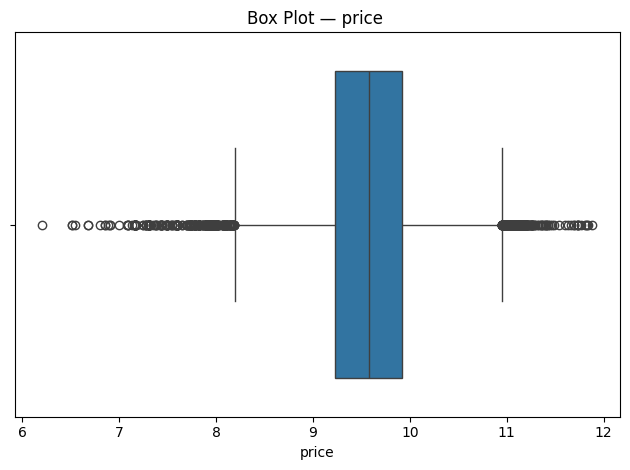

In [32]:
Q1 = y_train['price'].quantile(0.25)
Q3 = y_train['price'].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
outliers_iqr = y_train[(df['price'] < lower) | (y_train['price'] > upper)]
print(f'IQR outliers in price: {len(outliers_iqr)}')
sns.boxplot(data=y_train,x='price')
plt.title('Box Plot — price ')
plt.xlabel('price')
plt.tight_layout()
plt.show()

<Axes: xlabel='price', ylabel='Count'>

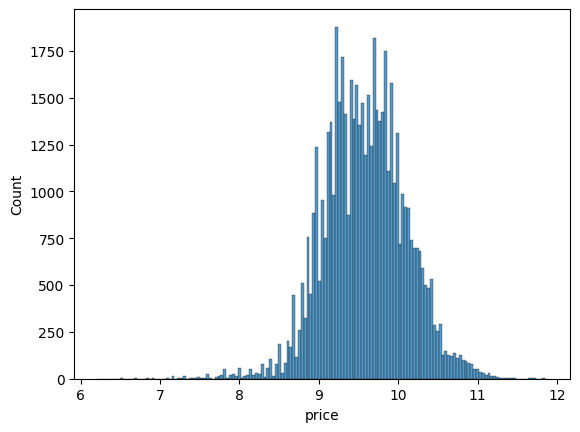

In [33]:
sns.histplot(data=y_train,x='price')

"After applying Log Transformation to the price, the distribution successfully shifted from right-skewed to a normal distribution (Gaussian-like), and the impact of extreme outliers was significantly minimized as shown in the boxplot.

### **Handling Missing Values**

In [34]:
df.isnull().sum()

model           3620
price           3607
transmission    3622
mileage         3592
fuelType        3619
tax             3619
mpg             3621
engineSize      3619
Make            3620
car_age         3622
dtype: int64

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 72069 entries, 0 to 72434
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         68449 non-null  object 
 1   price         68462 non-null  float64
 2   transmission  68447 non-null  object 
 3   mileage       68477 non-null  float64
 4   fuelType      68450 non-null  object 
 5   tax           68450 non-null  float64
 6   mpg           68448 non-null  float64
 7   engineSize    68450 non-null  float64
 8   Make          68449 non-null  object 
 9   car_age       68447 non-null  float64
dtypes: float64(6), object(4)
memory usage: 8.1+ MB


In [36]:
df.head()

,model,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make,car_age
0,A1,12500.0,Manual,15735.0,Petrol,150.0,55.4,1.4,audi,9.0
1,A6,16500.0,Automatic,36203.0,Diesel,20.0,64.2,2.0,audi,10.0
2,A1,11000.0,Manual,29946.0,Petrol,30.0,55.4,1.4,audi,10.0
3,A4,16800.0,Automatic,25952.0,Diesel,145.0,67.3,2.0,audi,9.0
4,A3,17300.0,Manual,1998.0,Petrol,145.0,49.6,1.0,audi,7.0


In [37]:
category_col = x_train.select_dtypes(include='O').columns.tolist()
categorical_imputer = SimpleImputer(strategy="most_frequent")
x_train[category_col] = categorical_imputer.fit_transform(x_train[category_col])


In [38]:
x_test[category_col] = categorical_imputer.transform(x_test[category_col])

In [39]:
numeric_col = x_train.select_dtypes(include=np.number).columns.tolist()
numeric_imputer = SimpleImputer(strategy='median')
x_train[numeric_col] = numeric_imputer.fit_transform(x_train[numeric_col])

In [40]:
x_test[numeric_col] = numeric_imputer.transform(x_test[numeric_col])

In [41]:
x_train.head()

,model,transmission,mileage,fuelType,tax,mpg,engineSize,Make,car_age
41911,Golf,Manual,6.216606,Petrol,145.0,3.856510,1.5,vw,1.945910
6839,Q3,Semi-Auto,8.466110,Petrol,145.0,3.487375,2.0,audi,2.079442
693,TT,Manual,9.872203,Petrol,165.0,3.856510,2.0,audi,2.484907
33529,Fiesta,Manual,9.868378,Diesel,145.0,4.492001,1.5,Ford,2.079442
28776,Fiesta,Manual,10.419032,Petrol,125.0,4.012773,1.2,Ford,2.484907


In [42]:
x_train.isnull().sum()

model           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
Make            0
car_age         0
dtype: int64

In [43]:
x_test.isnull().sum()

model           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
Make            0
car_age         0
dtype: int64

In [44]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 57655 entries, 41911 to 5216
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         57655 non-null  object 
 1   transmission  57655 non-null  object 
 2   mileage       57655 non-null  float64
 3   fuelType      57655 non-null  object 
 4   tax           57655 non-null  float64
 5   mpg           57655 non-null  float64
 6   engineSize    57655 non-null  float64
 7   Make          57655 non-null  object 
 8   car_age       57655 non-null  float64
dtypes: float64(5), object(4)
memory usage: 4.4+ MB


# **Encoding Categorical Variables**

In [45]:
x_train.head()

,model,transmission,mileage,fuelType,tax,mpg,engineSize,Make,car_age
41911,Golf,Manual,6.216606,Petrol,145.0,3.856510,1.5,vw,1.945910
6839,Q3,Semi-Auto,8.466110,Petrol,145.0,3.487375,2.0,audi,2.079442
693,TT,Manual,9.872203,Petrol,165.0,3.856510,2.0,audi,2.484907
33529,Fiesta,Manual,9.868378,Diesel,145.0,4.492001,1.5,Ford,2.079442
28776,Fiesta,Manual,10.419032,Petrol,125.0,4.012773,1.2,Ford,2.484907


In [46]:
for col in x_train.select_dtypes(include='O').columns:
    print(f"{col} : {x_train[col].nunique()}")
    print()
    

model : 144

transmission : 4

fuelType : 5

Make : 7



"For categorical features, One-Hot Encoding was applied to 'transmission' and 'fuelType' due to their low cardinality. For 'model' and 'Make', which have high cardinality (144 and 7 unique values),  Label Encoding  or Binary Encoding is preferred to prevent high dimensionality and maintain model performance

In [47]:
one_hot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
train_enc = one_hot.fit_transform(x_train[['transmission' ,'fuelType']])
test_enc = one_hot.transform(x_test[['transmission' ,'fuelType']])

In [48]:
cols_name = one_hot.get_feature_names_out(['transmission' ,'fuelType'])

train_ohe = pd.DataFrame(
 train_enc,
 columns=cols_name,
 index=x_train.index
)
test_ohe = pd.DataFrame(
 test_enc,
 columns=cols_name,
 index=x_test.index
)



In [49]:
x_train = pd.concat(
 [x_train.drop(['transmission' ,'fuelType'], axis=1),
 train_ohe],
 axis=1
)

x_test = pd.concat(
 [x_test.drop(['transmission' ,'fuelType'], axis=1),
 test_ohe],
 axis=1
)


In [50]:
be = ce.BinaryEncoder(cols=['Make', 'model'])
x_train = be.fit_transform(x_train)
x_test = be.transform(x_test)

"Binary Encoding was used for high-cardinality categorical features like 'model' to reduce dimensionality compared to One-Hot Encoding, and to avoid introducing an artificial order (ordinality) that comes with Label Encoding, which helps maintain model stability and performance

In [51]:
x_train

,model_0,model_1,model_2,model_3,model_4,model_5,model_6,model_7,mileage,tax,...,car_age,transmission_Automatic,transmission_Manual,transmission_Other,transmission_Semi-Auto,fuelType_Diesel,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
41911,0,0,0,0,0,0,0,1,6.216606,145.0,...,1.945910,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
6839,0,0,0,0,0,0,1,0,8.466110,145.0,...,2.079442,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
693,0,0,0,0,0,0,1,1,9.872203,165.0,...,2.484907,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
33529,0,0,0,0,0,1,0,0,9.868378,145.0,...,2.079442,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
28776,0,0,0,0,0,1,0,0,10.419032,125.0,...,2.484907,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49335,0,0,0,1,0,0,0,0,11.482477,165.0,...,2.944439,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
20720,0,0,0,1,0,0,1,1,9.790543,145.0,...,2.397895,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
21551,0,0,1,0,1,0,1,1,10.188591,145.0,...,2.302585,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
50297,0,0,0,0,0,1,0,0,9.666942,125.0,...,2.302585,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


# **Scale numerical features**

In [52]:
nums_col = ['mileage', 'tax', 'mpg', 'engineSize', 'car_age']
scaler = StandardScaler()
x_train[nums_col] = scaler.fit_transform(x_train[nums_col])
x_test[nums_col] = scaler.transform(x_test[nums_col])



In [53]:
x_train.head()

,model_0,model_1,model_2,model_3,model_4,model_5,model_6,model_7,mileage,tax,...,car_age,transmission_Automatic,transmission_Manual,transmission_Other,transmission_Semi-Auto,fuelType_Diesel,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
41911,0,0,0,0,0,0,0,1,-2.167388,0.424226,...,-1.749962,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
6839,0,0,0,0,0,0,1,0,-0.663291,0.424226,...,-1.044248,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
693,0,0,0,0,0,0,1,1,0.276872,0.742932,...,1.098634,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
33529,0,0,0,0,0,1,0,0,0.274315,0.424226,...,-1.044248,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
28776,0,0,0,0,0,1,0,0,0.642501,0.105520,...,1.098634,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


"The final preprocessed dataset consists of 25 features where categorical variables are binary-encoded and continuous numerical features are log-transformed and standardized. This structure eliminates magnitude bias and ensures the data follows the assumptions required for a high-performing Linear Regression model.